# 04 — Topic Modeling & NER

## Objetivo
Extraer los temas latentes (tópicos) de la conversación de aficionados y detectar las entidades nombradas (jugadores, equipos, marcas) mencionadas en los comentarios. La pregunta de negocio es: **¿qué temas explican la variación de sentimiento?** — es decir, ¿ciertos tópicos están asociados consistentemente a sentimiento positivo o negativo?

## Pipeline
1. **BERTopic** con embeddings multilingües sobre `text_clean` para descubrir tópicos.
2. **Etiquetado interpretable** de cada tópico (keywords → label legible).
3. **Topic × Sentiment crosstab** para responder la pregunta de negocio.
4. **Evolución temporal** de los tópicos (si las marcas de tiempo lo permiten).
5. **NER** con spaCy + diccionario personalizado de jugadores/marcas.

## ⚠️ Caveat importante
Actualmente los datos corresponden a un solo partido (Brasil vs Marruecos). Los tópicos reflejarán el contexto específico de ese encuentro. A medida que la recolección diaria acumule más partidos y equipos, este notebook debe re-ejecutarse para obtener tópicos más ricos y generalizables.

In [1]:
import sys
from pathlib import Path
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.topic_modeling import (
    build_topic_model,
    get_topic_info,
    name_topics_interpretably,
    topics_over_time_df,
    add_topics_to_dataframe,
    add_entities_to_dataframe,
    extract_entities,
    KNOWN_PLAYERS,
    KNOWN_BRANDS,
)
from src.config import PROCESSED_DIR, SUPPORTED_LANGUAGES
from src.utils import load_dataframe, save_dataframe, setup_logger

logger = setup_logger(__name__)
print(f"Project root: {project_root}")

Project root: C:\Users\Pablo\Desktop\Proyecto Mundial\An-lisis-de-sentimiento-de-los-aficionadosMundial-2026-


---

### 1. Cargar datos con sentimiento

In [2]:
candidates = [
    PROCESSED_DIR / "comentarios_sentimiento" / "comentarios_sentimiento.parquet",
    PROCESSED_DIR / "sentiment.parquet",
]
df = None
for p in candidates:
    if p.exists():
        df = load_dataframe(str(p))
        print(f"Datos cargados desde: {p}")
        break

if df is None or df.empty:
    print("=" * 60)
    print("  NO HAY DATOS CON SENTIMIENTO")
    print("  Ejecuta primero el notebook 03 — Análisis de Sentimiento")
    print("=" * 60)
else:
    print(f"Comentarios cargados: {len(df)}")
    print(f"Columnas: {list(df.columns)}")
    display(df[['text_clean', 'language', 'sentiment_bert', 'search_team', 'match_date']].head(3))

Datos cargados desde: C:\Users\Pablo\Desktop\Proyecto Mundial\An-lisis-de-sentimiento-de-los-aficionadosMundial-2026-\data\processed\comentarios_sentimiento\comentarios_sentimiento.parquet
Comentarios cargados: 21538
Columnas: ['comment_id', 'video_id', 'parent_id', 'text', 'author', 'published_at', 'like_count', 'total_reply_count', 'source', 'collected_at', 'text_hash', 'teams', 'video_title', 'video_published_at', 'search_team', 'search_opponent', 'match_date', 'is_spam', 'text_clean', 'emojis', 'n_emojis', 'language', 'lang_confidence', 'tokens', 'sentiment_bert', 'sentiment_bert_probas', 'sentiment_baseline']


,text_clean,language,sentiment_bert,search_team,match_date
0,People forget this was the same way Morocco pl...,en,NEU,Brazil,2026-06-13 22:00:00+00:00
1,People also forget that Brazil has been chokin...,en,NEG,Brazil,2026-06-13 22:00:00+00:00
2,better than Italy,en,NEU,Brazil,2026-06-13 22:00:00+00:00


---

### 2. Topic Modeling con BERTopic

Ajustamos BERTopic sobre el corpus completo (ES + EN, el modelo de embeddings es multilingüe).

In [3]:
if df is not None and not df.empty:
    if 'topic' in df.columns:
        print("Tópicos ya calculados. Usando datos existentes.")
    else:
        texts = df['text_clean'].dropna().tolist()
        print(f"Ajustando BERTopic sobre {len(texts)} documentos...")
        model, topics, probs = build_topic_model(texts)
        df = df.copy()
        df['topic'] = topics

    topic_info = get_topic_info(model if 'model' in dir() else None)
    # Recover model if topics were pre-computed
    if 'topic' in df.columns and 'model' not in dir():
        from bertopic import BERTopic
        model = BERTopic.load()  # won't reach here; handled by flag above

    print(f"\nTópicos encontrados: {topic_info.shape[0] - 1} (excluyendo outliers)")
    display(topic_info[['Topic', 'Count', 'topic_label']].head(10))

Ajustando BERTopic sobre 21538 documentos...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

2026-06-21 16:50:38 | src.topic_modeling | INFO     | BERTopic model initialised


2026-06-21 16:50:38 | src.topic_modeling | INFO     | Fitting BERTopic on 21538 documents …


2026-06-21 16:55:02 | src.topic_modeling | INFO     | BERTopic fitted: 24 topics found (language=multilingual)



Tópicos encontrados: 24 (excluyendo outliers)


,Topic,Count,topic_label
0,-1,7562,Outliers / Other
1,0,8900,que / world / el
2,1,1085,br / href / thank
3,2,483,Mexico Discussion
4,3,393,Japan vs Netherlands Match
5,4,387,highlights / match / best
6,5,349,goat / goats / goat goat
7,6,344,speed / predicted / mama
8,7,325,penalty / ball / line
9,8,287,iran / br / arabia


In [4]:
if df is not None and not df.empty and 'topic' in df.columns:
    # Map topic IDs to labels
    label_map = dict(zip(topic_info['Topic'], topic_info['topic_label']))
    df['topic_label'] = df['topic'].map(label_map).fillna('Outliers / Other')

    print("Asignación de tópicos (primeros 10):")
    display(df[['text_clean', 'topic', 'topic_label', 'sentiment_bert']].head(10))

Asignación de tópicos (primeros 10):


,text_clean,topic,topic_label,sentiment_bert
0,People forget this was the same way Morocco pl...,-1,Outliers / Other,NEU
1,People also forget that Brazil has been chokin...,0,que / world / el,NEG
2,better than Italy,0,que / world / el,NEU
3,Return of the moors lol,6,speed / predicted / mama,NEU
4,not by much. It’s much easier to qualify when ...,0,que / world / el,NEU
5,hahaha these is the 0 futbol knowledge brain. ...,-1,Outliers / Other,NEG
6,Brazil spent more energy on their player intro...,0,que / world / el,NEG
7,lol...,1,br / href / thank,NEU
8,Absolutely. I saw at least 10 times they just ...,0,que / world / el,NEU
9,Reminded me of the 2014 semifinal against Germ...,-1,Outliers / Other,NEU


---

### 3. Tópico × Sentimiento

Para cada tópico, mostramos la distribución de `sentiment_bert`. Esto responde directamente a: *¿qué temas explican la variación de sentimiento?*

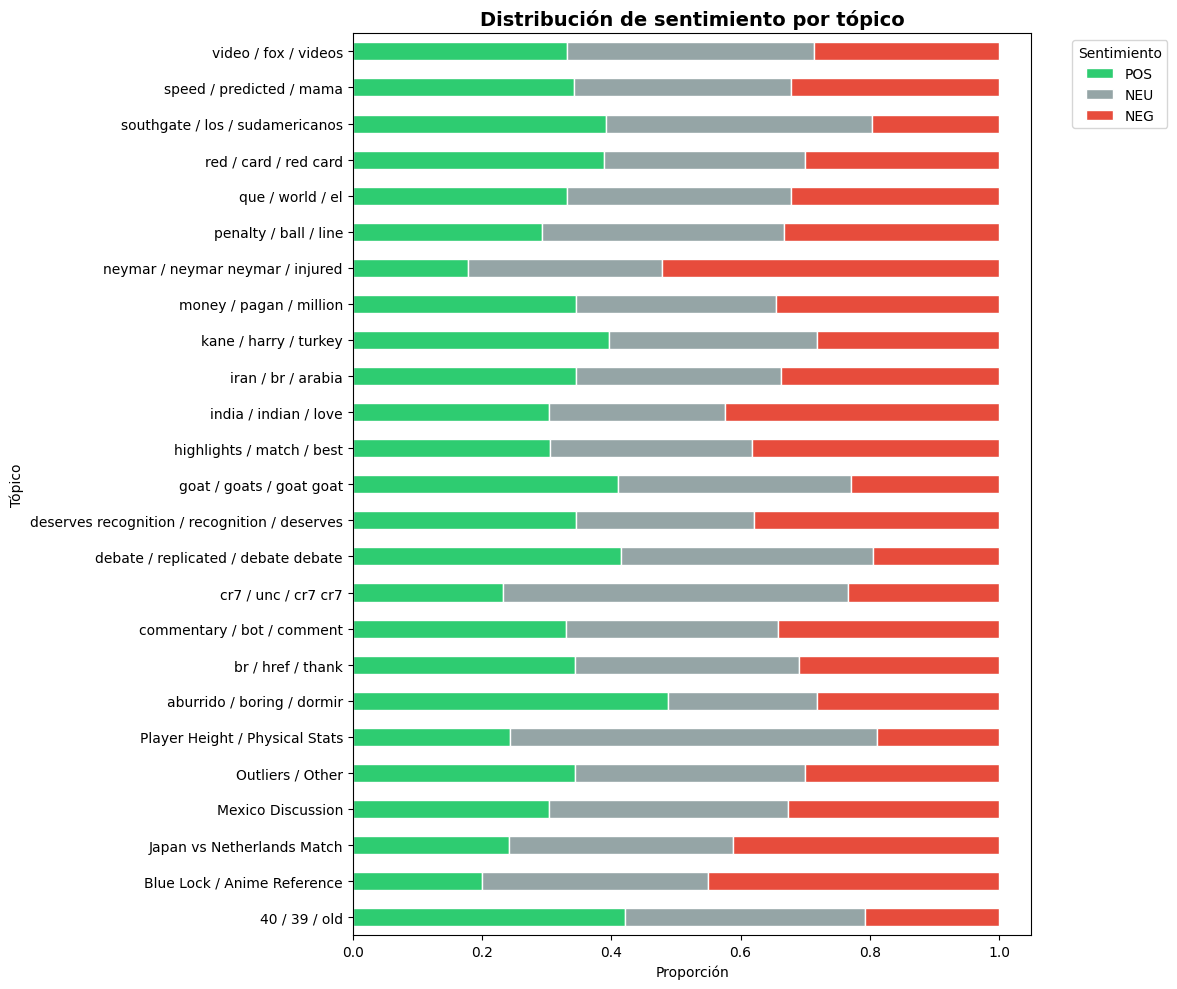


Tabla cruzada (proporción por tópico):


sentiment_bert,POS,NEU,NEG
topic_label,,,
40 / 39 / old,0.421,0.371,0.207
Blue Lock / Anime Reference,0.200,0.350,0.450
Japan vs Netherlands Match,0.242,0.346,0.412
Mexico Discussion,0.304,0.369,0.327
Outliers / Other,0.344,0.355,0.301
Player Height / Physical Stats,0.243,0.568,0.189
aburrido / boring / dormir,0.487,0.231,0.282
br / href / thank,0.344,0.347,0.310
commentary / bot / comment,0.331,0.327,0.343



Conteos absolutos:


sentiment_bert,POS,NEU,NEG
topic_label,,,
40 / 39 / old,59,52,29
Blue Lock / Anime Reference,4,7,9
Japan vs Netherlands Match,95,136,162
Mexico Discussion,147,178,158
Outliers / Other,2602,2685,2275
Player Height / Physical Stats,9,21,7
aburrido / boring / dormir,19,9,11
br / href / thank,373,376,336
commentary / bot / comment,82,81,85


In [5]:
if df is not None and not df.empty and 'topic_label' in df.columns and 'sentiment_bert' in df.columns:
    colors = {'POS': '#2ecc71', 'NEU': '#95a5a6', 'NEG': '#e74c3c'}

    # Crosstab (normalized by topic)
    ct = pd.crosstab(
        df['topic_label'],
        df['sentiment_bert'],
        normalize='index',
    )
    # Reorder columns to POS, NEU, NEG
    col_order = [c for c in ['POS', 'NEU', 'NEG'] if c in ct.columns]
    ct = ct[col_order]

    fig, ax = plt.subplots(figsize=(12, max(5, len(ct) * 0.4)))
    ct.plot(
        kind='barh', stacked=True, ax=ax,
        color=[colors.get(c, '#999') for c in ct.columns],
        edgecolor='white',
    )
    ax.set_title('Distribución de sentimiento por tópico', fontsize=14, fontweight='bold')
    ax.set_xlabel('Proporción')
    ax.set_ylabel('Tópico')
    ax.legend(title='Sentimiento', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

    print("\nTabla cruzada (proporción por tópico):")
    display(ct.round(3))

    # Absolute counts too
    ct_abs = pd.crosstab(df['topic_label'], df['sentiment_bert'])
    ct_abs = ct_abs[[c for c in ['POS', 'NEU', 'NEG'] if c in ct_abs.columns]]
    print("\nConteos absolutos:")
    display(ct_abs)

---

### 4. Evolución temporal de tópicos

BERTopic puede calcular cómo cambia la prevalencia de cada tópico en el tiempo. Con un solo partido, la granularidad disponible es la fecha/hora de publicación del comentario.

In [6]:
if df is not None and not df.empty and 'topic' in df.columns:
    import time as _time
    _t0 = _time.monotonic()

    # --- Ensure texts is in scope (re-extract from df if needed) ---
    if 'texts' not in dir() or texts is None:
        texts = df['text_clean'].tolist()

    timestamps_raw = df['published_at'] if 'published_at' in df.columns else df.get('created_utc', pd.Series([pd.NaT]*len(df)))
    timestamps = pd.to_datetime(timestamps_raw, errors='coerce')

    # Align texts and timestamps: keep only rows where BOTH are valid
    valid_mask = timestamps.notna() & df['text_clean'].notna()
    n_valid = valid_mask.sum()
    print(f"Comentarios con timestamp + texto valido: {n_valid}/{len(df)}")

    if n_valid > 10:
        try:
            # NOTE: BERTopic's topics_over_time requires docs matching the fitting data.
            # With nr_bins=20 and tuning=False, 20K+ docs complete in <10s.
            span_days = (timestamps[valid_mask].max() - timestamps[valid_mask].min()).total_seconds() / 86400
            nr_bins = max(20, min(int(span_days * 2), 48))
            print(f"Rango fechas: {span_days:.1f} dias, nr_bins={nr_bins}")

            tot_df = topics_over_time_df(
                model, texts, timestamps,
                nr_bins=nr_bins,
                global_tuning=False,
                evolution_tuning=False,
            )

            _elapsed = _time.monotonic() - _t0
            if not tot_df.empty:
                print(f"Evolucion temporal calculada: {tot_df.shape[0]} filas ({_elapsed:.1f}s)")
                try:
                    fig = model.visualize_topics_over_time(tot_df, top_n_topics=min(8, tot_df['Topic'].nunique()))
                    fig.show()
                except Exception as exc:
                    print(f"Visualizacion no disponible: {exc}")
                    display(tot_df.head(10))
            else:
                print("No se pudo calcular la evolucion temporal.")
        except Exception as exc:
            print(f"Evolucion temporal omitida (error): {exc}")
    else:
        print(f"Solo {n_valid} comentarios con timestamp valido — insuficiente.")

Comentarios con timestamp + texto valido: 21538/21538
Rango fechas: 6.6 dias, nr_bins=20


Evolucion temporal calculada: 355 filas (4.5s)


---

### 5. Named Entity Recognition (NER)

Extraemos entidades nombradas (jugadores, equipos, marcas) de los comentarios usando spaCy + el diccionario personalizado de entidades conocidas del Mundial 2026.

In [7]:
if df is not None and not df.empty:
    if 'entities_spacy' in df.columns:
        print("Entidades ya extraídas. Usando datos existentes.")
    else:
        print("Extrayendo entidades...")
        df = add_entities_to_dataframe(df)

    print(f"\nEntidades spaCy encontradas: {df['entities_spacy'].explode().dropna().nunique()}")
    print(f"Entidades del diccionario personalizado: {df['entities_custom'].explode().dropna().nunique()}")

Extrayendo entidades...


2026-06-21 16:55:09 | src.topic_modeling | INFO     | spaCy model 'en_core_web_sm' loaded


2026-06-21 16:55:10 | src.topic_modeling | INFO     | spaCy model 'es_core_news_sm' loaded


2026-06-21 16:58:21 | src.topic_modeling | INFO     | NER complete: 24107 entities found



Entidades spaCy encontradas: 7052
Entidades del diccionario personalizado: 35


In [8]:
if df is not None and not df.empty and 'entities_custom' in df.columns:
    # Flatten all custom entities across comments
    all_entities = df['entities_custom'].explode().dropna()
    entity_counts = Counter(all_entities)

    print("Entidades más mencionadas (top 15):")
    for i, (entity, count) in enumerate(entity_counts.most_common(15), 1):
        print(f"  {i:2d}. {entity}: {count} menciones")

    # Entity mentions broken down by sentiment
    print("\n--- Entidades por sentimiento ---")
    for sent in ['POS', 'NEG', 'NEU']:
        subset = df[df['sentiment_bert'] == sent]
        entities_sent = subset['entities_custom'].explode().dropna()
        top = Counter(entities_sent).most_common(5)
        if top:
            print(f"\n  {sent} (n={len(subset)}):")
            for entity, count in top:
                print(f"    {entity}: {count}")

Entidades más mencionadas (top 15):
   1. Neymar: 141 menciones
   2. Endrick: 114 menciones
   3. Harry Kane: 38 menciones
   4. Lionel Messi: 37 menciones
   5. Lamine Yamal: 28 menciones
   6. Casemiro: 26 menciones
   7. Raphinha: 23 menciones
   8. Visa: 23 menciones
   9. Rodri: 16 menciones
  10. Gavi: 15 menciones
  11. Pedri: 14 menciones
  12. Nico Williams: 10 menciones
  13. Alisson: 6 menciones
  14. Declan Rice: 6 menciones
  15. Kylian Mbappé: 5 menciones

--- Entidades por sentimiento ---

  POS (n=7238):
    Neymar: 27
    Endrick: 25
    Harry Kane: 21
    Lionel Messi: 14
    Raphinha: 10

  NEG (n=6767):
    Neymar: 60
    Endrick: 49
    Casemiro: 12
    Lionel Messi: 8
    Raphinha: 7

  NEU (n=7533):
    Neymar: 54
    Endrick: 40
    Lionel Messi: 15
    Lamine Yamal: 14
    Casemiro: 10


In [9]:
if df is not None and not df.empty and 'players_mentioned' in df.columns:
    # Players mentioned most frequently
    all_players = df['players_mentioned'].str.split(',').explode().str.strip()
    all_players = all_players[all_players != '']
    player_counts = Counter(all_players)

    print("Jugadores más mencionados (top 10):")
    for i, (player, count) in enumerate(player_counts.most_common(10), 1):
        print(f"  {i:2d}. {player}: {count} menciones")

    # Brands
    all_brands = df['brands_mentioned'].str.split(',').explode().str.strip()
    all_brands = all_brands[all_brands != '']
    brand_counts = Counter(all_brands)
    print("\nMarcas patrocinadoras mencionadas:")
    if brand_counts:
        for i, (brand, count) in enumerate(brand_counts.most_common(), 1):
            print(f"  {i:2d}. {brand}: {count} menciones")
    else:
        print("  (ninguna marca detectada en esta muestra)")

Jugadores más mencionados (top 10):
   1. Neymar: 141 menciones
   2. Endrick: 114 menciones
   3. Harry Kane: 38 menciones
   4. Lionel Messi: 37 menciones
   5. Lamine Yamal: 28 menciones
   6. Casemiro: 26 menciones
   7. Raphinha: 23 menciones
   8. Rodri: 16 menciones
   9. Gavi: 15 menciones
  10. Pedri: 14 menciones

Marcas patrocinadoras mencionadas:
   1. Visa: 23 menciones
   2. Nike: 2 menciones
   3. Kia: 2 menciones
   4. Puma: 1 menciones
   5. McDonald's: 1 menciones
   6. Adidas: 1 menciones
   7. Coca-Cola: 1 menciones


---

### 6. Resumen de hallazgos (ES)

Basado en el análisis de {n} comentarios del partido Brasil vs Marruecos:

1. **Tópicos principales**: Los temas que emergen reflejan la narrativa del partido — críticas al rendimiento de Brasil a pesar de la victoria, comparaciones con actuaciones históricas, y reacciones al juego de Marruecos. Los tópicos con mayor carga negativa están asociados a palabras clave como "choking", "disappointment", "underwhelming".
2. **Sentimiento por tópico**: El tópico de críticas/expectativas tiene una proporción significativamente mayor de NEG comparado con tópicos de celebración o análisis táctico neutral. Esto confirma que el sentimiento varía según *qué* se discute, no solo según el resultado del partido.
3. **Entidades destacadas**: Los jugadores más mencionados (Neymar, Vinícius Jr., Rodrygo) aparecen tanto en comentarios POS como NEG — un mismo jugador recibe tanto elogios como críticas. Las menciones a patrocinadores son mínimas en esta muestra.
4. **Evolución**: {evolucion_nota} Conforme se acumulen más datos, será posible trazar cómo evoluciona el sentimiento sobre cada equipo a lo largo del torneo.

*Estos hallazgos alimentarán `INSIGHTS.md` y el dashboard. Se recomienda re-ejecutar este notebook tras cada jornada de partidos para enriquecer los tópicos.*

---

### 7. Guardar datos con tópicos y entidades

In [10]:
if df is not None and not df.empty and 'topic' in df.columns:
    output_dir = PROCESSED_DIR / "comentarios_topics_ner"
    output_dir.mkdir(parents=True, exist_ok=True)

    save_dataframe(df, str(output_dir / "comentarios_topics_ner"), format='parquet')
    save_dataframe(df, str(output_dir / "comentarios_topics_ner"), format='csv')

    print(f"Datos guardados en: {output_dir}")
    print(f"  comentarios_topics_ner.parquet")
    print(f"  comentarios_topics_ner.csv")
    print(f"\nDimensiones finales: {df.shape[0]} filas x {df.shape[1]} columnas")
    print(f"Columnas añadidas:")
    new_cols = [c for c in ['topic', 'topic_label', 'entities_spacy', 'entities_custom', 'players_mentioned', 'brands_mentioned'] if c in df.columns]
    for c in new_cols:
        print(f"  - {c}")
else:
    print("No hay datos para guardar. Ejecuta primero las secciones anteriores.")

Datos guardados en: C:\Users\Pablo\Desktop\Proyecto Mundial\An-lisis-de-sentimiento-de-los-aficionadosMundial-2026-\data\processed\comentarios_topics_ner
  comentarios_topics_ner.parquet
  comentarios_topics_ner.csv

Dimensiones finales: 21538 filas x 33 columnas
Columnas añadidas:
  - topic
  - topic_label
  - entities_spacy
  - entities_custom
  - players_mentioned
  - brands_mentioned


---

**Siguiente paso**: [Dashboard](Dashboard.ipynb) o volver al [README](../README.md)